In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
firm_effects = pd.read_csv("data/white_posterior_features.csv")

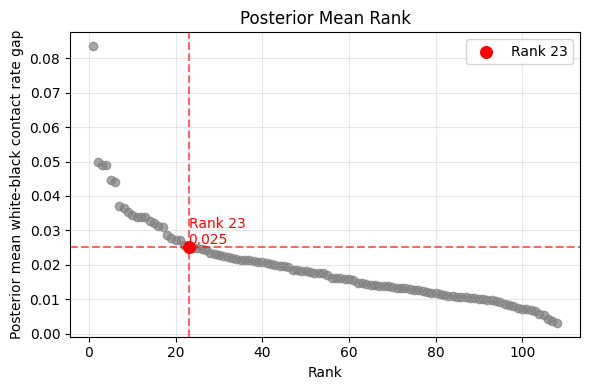

In [3]:
y = firm_effects["post_mean_beta"]

# Create a DataFrame with ranks
df = pd.DataFrame({
    "post_mean_beta": y,
    "rank": y.rank(method="first", ascending=False)  # assign unique ranks
}).sort_values("rank")

# Identify the 23rdh ranked observation
highlight_rank = 23
highlight_point = df.loc[df["rank"].eq(highlight_rank)].iloc[0]

# Plot
plt.figure(figsize=(6, 4))
plt.scatter(df["rank"], df["post_mean_beta"], color="gray", alpha=0.7)
plt.scatter(highlight_point["rank"], highlight_point["post_mean_beta"], color="red", s=70, label=f"Rank {highlight_rank}")
# Add dashed guide lines
plt.axvline(x=highlight_point["rank"], color="red", linestyle="--", alpha=0.6)
plt.axhline(y=highlight_point["post_mean_beta"], color="red", linestyle="--", alpha=0.6)

# Add text label for the highlighted point
plt.text(
    highlight_point["rank"],
    highlight_point["post_mean_beta"],
    f"Rank {highlight_rank}\n{highlight_point['post_mean_beta']:.3f}",
    color="red",
    ha="left", va="bottom"
)


# Labels and style
plt.xlabel("Rank")
plt.ylabel(r"Posterior mean white-black contact rate gap")
plt.title("Posterior Mean Rank")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
# Save the figure as PDF
plt.savefig("firm_gaps_white_posterior_mean_rank.pdf", format="pdf", bbox_inches="tight")

plt.show()

In [4]:
# firm_effects_white = pd.read_csv("data/firm_effects_white.csv")
estimates = firm_effects["est"].values
standard_errors = firm_effects["se"].values
Xs = estimates
sigmas = standard_errors
ts = Xs/sigmas
n = len(Xs)

grand_mean = np.mean(estimates)
grand_var = np.var(Xs) - np.mean(sigmas**2)

In [5]:
import scipy 
from scipy.optimize import minimize, approx_fprime
from scipy.special import sici
from scipy.optimize import dual_annealing, approx_fprime

def opt_dirichlet(Xs, sigmas, K, x0=0, lb=-50, ub=50):
    """
    Directly optimizes the Dirichlet objective over a 1D parameter c
    """

    Xs = np.asarray(Xs, dtype=float)
    sigmas = np.asarray(sigmas, dtype=float)
    ts = Xs / sigmas
    n = len(Xs)
    assert sigmas.shape == Xs.shape, "Xs and sigmas must have the same shape."

    # Objective function (negative welfare so we maximize welfare)
    def objective(c):
        h_n = 1.0 / np.sqrt(2 * np.log(n))

        u = (ts[:, None] - K/sigmas[:, None] - c * sigmas[:, None]) / h_n

        Si_u, _ = sici(u)
        sinc_u = np.sinc(u / np.pi) / np.pi

        T1 = 0.5 * np.sum(Xs - K)
        T2 = ((Xs[:, None] - K) * Si_u).sum(axis=0) / np.pi
        T3 = -((sigmas[:, None] / h_n) * sinc_u).sum(axis=0)

        welfare = (T1 + T2 + T3) / n
        return -welfare  # negative since we maximize


    # Bounds: c in [lb, ub]
    bounds = [(lb, ub)]
    
    
    # Run the minimizer with bounds
    result = dual_annealing(
        objective,
        bounds=bounds,
    )

    optimal_c = result.x.item()
    max_welfare = -result.fun.item()

    return optimal_c, max_welfare

In [6]:
def dirichlet_gain(Xs, sigmas, K, c):
    """
    Use Dirichlet estimator to estimate the welfare given c and return the treated share
    """

    Xs = np.asarray(Xs, dtype=float)
    sigmas = np.asarray(sigmas, dtype=float)
    ts = Xs / sigmas
    n = len(Xs)
    assert sigmas.shape == Xs.shape, "Xs and sigmas must have the same shape."

    h_n = 1.0 / np.sqrt(2 * np.log(n))

    # c1, c2 = c  # if both are parameters
    # u = (ts[:, None] - K/sigmas[:, None] - (K-c1)* sigmas[:, None]/c2 ) / h_n # threshold by K
    u = (ts[:, None] - K/sigmas[:, None] - c* sigmas[:, None] ) / h_n # threshold by K
    # SI(u): use scipy.special.sici, first element is Si
    Si_u, _ = sici(u)
    sinc_u = np.sinc(u / np.pi) / np.pi

    T1 = 0.5 * np.sum(Xs - K)
    T2 = (((Xs[:, None] ) - K) * Si_u).sum(axis=0) / np.pi
    T3 = -((sigmas[:, None] / h_n) * sinc_u).sum(axis=0)

    welfare = (T1 + T2 + T3) / n
                    
    return welfare

In [7]:
C_grid = np.linspace(-75,75, 200)
cost = 0.025
welfare_curve = np.zeros_like(C_grid).astype(float)
for i in np.arange(len(C_grid)):
    c = C_grid[i]
    welfare_curve[i] = dirichlet_gain(Xs, sigmas, K=cost, c=c)


/var/folders/ss/6b889brj7y5601808x613g_h0000gp/T/ipykernel_2814/3540966024.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  welfare_curve[i] = dirichlet_gain(Xs, sigmas, K=cost, c=c)


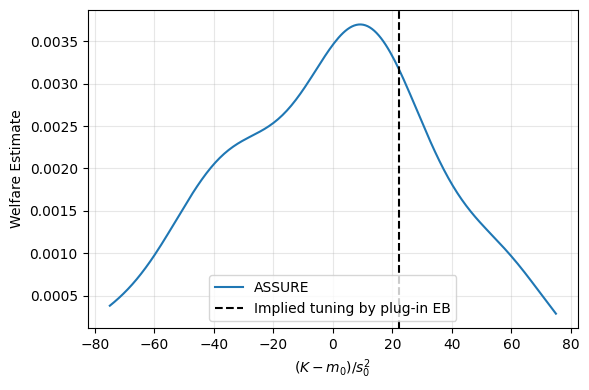

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))

# Plot the welfare curve
ax.plot(C_grid, welfare_curve, ls='-', label='ASSURE')

# Compute EB parameter and add a vertical line
eb_param = (cost - grand_mean) / grand_var
ax.axvline(x=eb_param, ls='--', color='k', label='Implied tuning by plug-in EB')

# Labels and legend
ax.set_xlabel(r'$(K - m_0)/s_0^2$')
ax.set_ylabel('Welfare Estimate')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("firm_gaps_white_objective_K_0025.pdf", bbox_inches='tight')
plt.show()

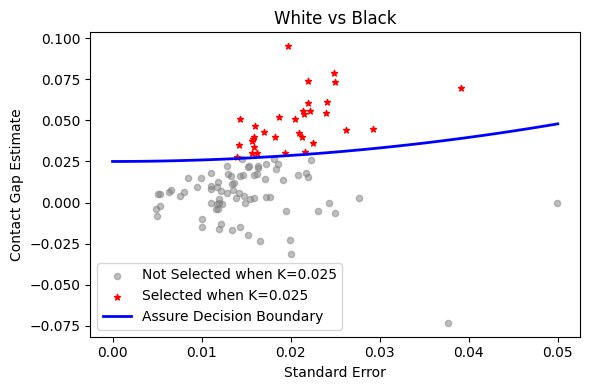

In [9]:
init_c = 0

optimal_c, max_welfare = opt_dirichlet(Xs, sigmas, K=cost, x0 = init_c)
# Compute u for selection
ts = Xs / sigmas
# c1, c2 = optimal_c   # use your optimal c
# u = ts - target_K / sigmas - (target_K - c1) * sigmas / c2
c = optimal_c
u = (ts - cost / sigmas - c * sigmas ) 
selected = u > 0
plt.figure(figsize=(6, 4))

# Plot non-selected firms
plt.scatter(standard_errors[~selected], estimates[~selected], s=20, color="gray", alpha=0.5, label=f'Not Selected when K={cost:.3f}')

# Plot selected firms
plt.scatter(standard_errors[selected], estimates[selected], s=20, color="red", marker="*", label=f'Selected when K={cost:.3f}')
# Decision boundary line: estimates = K + c * (SE^2)
sigmas_grid = np.arange(0, 0.051, 0.001)  # from 0 to 0.05 in steps of 0.001
line = cost + c * (sigmas_grid ** 2)
plt.plot(
    sigmas_grid, line, color="blue", linewidth=2,
    label='Assure Decision Boundary'
)

plt.title("White vs Black")
plt.xlabel("Standard Error")
plt.ylabel("Contact Gap Estimate")
plt.legend()
plt.tight_layout()
# plt.savefig("firm_gaps_white_estimates_vs_se_K_0025.pdf", bbox_inches='tight')
plt.show()


In [10]:
selected.sum()

np.int64(32)

In [11]:

firm_effects["u"] = u


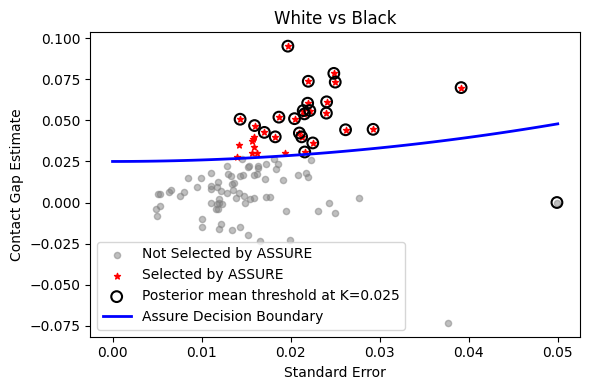

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Assume you already have:
# estimates, standard_errors, u, cost, c, merged

selected = firm_effects["u"] > 0
highlight = firm_effects["post_mean_beta"] > 0.025

plt.figure(figsize=(6, 4))

# --- Base layers ---
# Plot non-selected firms
plt.scatter(
    firm_effects["se"][~selected], firm_effects["est"][~selected],
    s=20, color="gray", alpha=0.5,
    label=f'Not Selected by ASSURE'
)

# Plot selected firms
plt.scatter(
    firm_effects["se"][selected], firm_effects["est"][selected],
    s=20, color="red", marker="*",
    label=f'Selected by ASSURE'
)

# --- Highlight layer ---
# Highlight firms with post_mean_beta > 0.023
plt.scatter(
    firm_effects["se"][highlight],
    firm_effects["est"][highlight],
    s=60, facecolors='none', edgecolors='black', linewidths=1.5,
    label=f'Posterior mean threshold at K={cost:.3f}'
)

# --- Decision boundary ---
sigmas_grid = np.arange(0, 0.051, 0.001)
line = cost + c * (sigmas_grid ** 2)
plt.plot(
    sigmas_grid, line, color="blue", linewidth=2,
    label='Assure Decision Boundary'
)

plt.title("White vs Black")
plt.xlabel("Standard Error")
plt.ylabel("Contact Gap Estimate")
plt.legend()
plt.tight_layout()
plt.savefig("firm_gaps_white_estimates_vs_se_K_0025.pdf", bbox_inches='tight')
plt.show()


In [13]:
firm_effects["selected"] = selected
firm_effects["highlight"] = highlight
# firm_effects.loc[:, ["selected", "highlight", "firm_id", "post_mean_beta", "est", "se"]]
